In [11]:
import gzip
import os
import io
import itertools
import numpy as np

In [5]:
os.getcwd()

'/scratch/gpfs/ziyangc/PASA/ScRNAseq/data/rawdata/test_cutadapt'

## Verify plate demultiplexing

In [2]:
dir1 = '../rawdata/r1r3_welldemultiplex_full/r3r1/A1.31.fastq.gz'
dir4 = '../rawdata/r1r4_welldemultiplex_full/r4/A1.4.fastq.gz'

In [3]:
start = 0
stop = start + 1
with gzip.open(dir1, 'rt') as read1, gzip.open(dir4, 'rt') as read4:
    line1 = next(itertools.islice(read1, start, stop))
    line4 = next(itertools.islice(read4, start, stop))
    print(line1)
    print(line4)

@A00741:740:HTNFLDRX5:1:2101:2076:1016 3:N:0:0

@A00741:740:HTNFLDRX5:1:2101:2076:1016 4:N:0:0



## verify combining

In [15]:
start = 1
stop = start + 1
with gzip.open(dir1, 'rt') as read1, gzip.open(dir3, 'rt') as read3, gzip.open(dir13, 'rt') as read13:
    line1 = next(itertools.islice(read1, start, stop))
    line3 = next(itertools.islice(read3, start, stop))
    line13 = next(itertools.islice(read13, start, stop))
    print(line1)
    print(line3)
    print(line13)

TNCCCGCCAAGTGATTAGCAAGCTAC

NACGCTGCCGACGACCTACGTTGGAAGGCT

NACGCTGCCGACGACCTACGTTGGAAGGCTTNCCCGCCAAGTGATTAGCAAGCTAC



## analyze read map statistics

In [4]:
import re
import pandas as pd
import os

In [3]:
os.getcwd()

'/scratch/gpfs/ziyangc/PASA/ScRNAseq/data/rawdata/test_cutadapt'

In [5]:
input_file = '../slurm_log/demultiplex_full_64335325.out'
# Initialize lists to store adapter names and trimmed times
adapter_names = []
trimmed_times = []
sequence_names = []

# Use regular expressions to extract the adapter name and trimmed times
adapter_pattern = re.compile(r"Adapter (\w+)")
trimmed_pattern = re.compile(r"Trimmed: (\d+) times")
sequence_pattern = re.compile(r"Sequence: (\w+)")

In [6]:
with open(input_file, 'r') as f:
    for line in f:
        adapter_match = adapter_pattern.search(line)
        trimmed_match = trimmed_pattern.search(line)
        sequence_match = sequence_pattern.search(line)
        if adapter_match:
            adapter_names.append(adapter_match.group(1))
        if trimmed_match:
            trimmed_times.append(int(trimmed_match.group(1)))
        if sequence_match:
            sequence_names.append(sequence_match.group(1))

In [7]:
# Create a dataframe to store the adapter names and trimmed times
out=pd.DataFrame()
out['adapter']=adapter_names
out['trimmed']=trimmed_times
out['sequence']=sequence_names

In [14]:
out = out.iloc[:96, :]

In [15]:
out.shape

(96, 3)

In [16]:
out['percent'] = out['trimmed'] / out['trimmed'].sum()

In [17]:
out.head()

,adapter,trimmed,sequence,percent
0,A4,1108315,TCAGCGCTGGTTA,0.003525
1,A5,4670293,TCAGCTTAATCGC,0.014853
2,A6,3790212,TCGCACGACGTAC,0.012054
3,B4,1563359,TGTTGACGAATAA,0.004972
4,B5,3698760,TGGCTTAAGAGAC,0.011764


In [18]:
out.shape

(96, 4)

In [19]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [20]:
# Set the number of rows and columns for your heatmap
n_rows = 8
n_cols = 12

# Select the first column from your DataFrame
data_to_plot = out.iloc[:, 3].values.reshape(n_rows, n_cols)

In [14]:
data_to_plot

array([[0.00300795, 0.00329036, 0.00745607, 0.0144462 , 0.01058642,
        0.02247766, 0.00212174, 0.00145324, 0.00273803, 0.00321572,
        0.00290772, 0.00566711],
       [0.00266666, 0.00424468, 0.01588951, 0.00747655, 0.00470113,
        0.00246922, 0.00813306, 0.01066351, 0.01254737, 0.01292237,
        0.01851546, 0.00806278],
       [0.0095816 , 0.01300033, 0.01351827, 0.01080872, 0.01813681,
        0.00582633, 0.0116283 , 0.00896337, 0.01847802, 0.01830155,
        0.02959386, 0.01277074],
       [0.02537085, 0.01129792, 0.02245058, 0.00956022, 0.01526303,
        0.00325462, 0.00549726, 0.01786794, 0.02137385, 0.00866576,
        0.01964979, 0.00677144],
       [0.00600678, 0.00589836, 0.01398271, 0.01046942, 0.02503074,
        0.01003578, 0.03034746, 0.01347129, 0.01992615, 0.0136793 ,
        0.00854917, 0.01729389],
       [0.01173401, 0.01378028, 0.01875105, 0.02340215, 0.00617826,
        0.01213017, 0.0112431 , 0.0157047 , 0.02036322, 0.00902608,
        0.00974906,

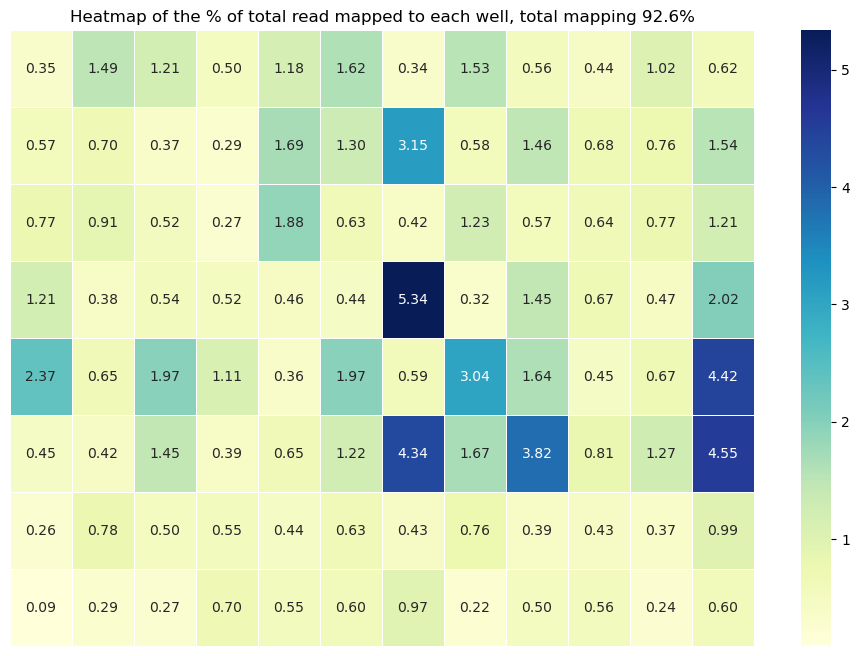

In [21]:
plt.figure(figsize=(12, 8))
sns.heatmap(data_to_plot*100, annot=True, cmap='YlGnBu', fmt='.2f', cbar=True, linewidths=.5, xticklabels=False, yticklabels=False)
plt.title('Heatmap of the % of total read mapped to each well, total mapping 92.6%')
plt.show()

## verify trim

In [16]:
dir_o = './plate_demux/read3a1/A1.read3a1.fastq.gz'
dir_t = './plate_demux/trimmed/A1.trimmed.fastq.gz'

In [17]:
start = 1
stop = start + 1
with gzip.open(dir_o, 'rt') as read_o, gzip.open(dir_t, 'rt') as read_t:
    line_o = next(itertools.islice(read_o, start, stop))
    line_t = next(itertools.islice(read_t, start, stop))
    print(line_o)
    print(line_t)

NACGCTGCCGACGACCTACGTTGGAAGGCTTNCCCGCCAAGTGATTAGCAAGCTAC

CCTACGTTGGAAGGCTTNCCCGCC

